In [1]:
import os
from typing import Optional, Union, Tuple

import torch
from torch import Tensor
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import Node2Vec


@torch.no_grad()
def _infer_device(device: Optional[Union[str, torch.device]] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def node2vec_gpu_embedding(
    edge_index: Tensor,
    num_nodes: int,
    embedding_dim: int = 128,
    walk_length: int = 20,
    context_size: int = 10,
    walks_per_node: int = 10,
    num_negative_samples: int = 1,
    p: float = 1.0,
    q: float = 1.0,
    sparse: bool = True,
    lr: float = 0.01,
    epochs: int = 50,
    batch_size: int = 256,
    num_workers: int = 0,
    device: Optional[Union[str, torch.device]] = None,
    seed: int = 42,
    log_every: int = 10,
) -> Tuple[Tensor, Node2Vec]:
    """
    Trains a PyG Node2Vec model and returns node embeddings.

    Notes on GPU:
      - The embedding model and loss run on GPU if `device='cuda'`.
      - Random walk sampling in PyG Node2Vec is typically performed on CPU via a DataLoader.
        This is normal: you'll still get GPU acceleration for the training step.

    Args:
        edge_index: LongTensor [2, E] with COO edges.
        num_nodes: Number of nodes in the graph.
        embedding_dim: Output embedding size.
        walk_length/context_size/walks_per_node: Node2Vec walk params.
        num_negative_samples: Negative samples per positive.
        p, q: Node2Vec return/in-out params.
        sparse: Use sparse gradients for embeddings (recommended for large graphs).
        lr: Learning rate.
        epochs: Training epochs.
        batch_size: Batch size for sampled walks.
        num_workers: DataLoader workers for sampling.
        device: 'cuda', 'cpu', or torch.device. If None, auto-detect.
        seed: Random seed.
        log_every: Print loss every `log_every` epochs.

    Returns:
        embeddings: FloatTensor [num_nodes, embedding_dim] on CPU.
        model: Trained torch_geometric.nn.Node2Vec model (on `device`).
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    dev = _infer_device(device)

    if edge_index.dtype != torch.long:
        edge_index = edge_index.long()
    edge_index = edge_index.contiguous()

    # Build PyG Node2Vec model:
    model = Node2Vec(
        edge_index=edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=context_size,
        walks_per_node=walks_per_node,
        num_negative_samples=num_negative_samples,
        p=p,
        q=q,
        num_nodes=num_nodes,
        sparse=sparse,
    ).to(dev)

    # Random walk loader (sampling usually on CPU, yielding walk tensors)
    loader = model.loader(
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    # Optimizer: SparseAdam is a good default for sparse embeddings
    if sparse:
        optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)
    else:
        optimizer = torch.optim.Adam(list(model.parameters()), lr=lr)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        total_batches = 0

        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()

            # Move random walks onto GPU for the loss computation
            pos_rw = pos_rw.to(dev, non_blocking=True)
            neg_rw = neg_rw.to(dev, non_blocking=True)

            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            optimizer.step()

            total_loss += float(loss)
            total_batches += 1

        avg_loss = total_loss / max(total_batches, 1)
        if log_every and (epoch % log_every == 0 or epoch == 1 or epoch == epochs):
            print(f"Epoch {epoch:03d}/{epochs} | loss={avg_loss:.4f}")

    model.eval()
    emb = model.embedding.weight.detach().cpu()  # [num_nodes, embedding_dim]
    return emb, model


In [2]:
import os
import sys
sys.path.insert(0 , '../MAIN/')

from helpers import plot_patient_embeddings
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels
import pandas as pd
from torch_geometric.utils import from_networkx, to_undirected

# --- Config ---
datadir    = "/work/gr-fe/bryan/data/SHCS/"
Gprefix    = "KGshcs"

# --- Load graphs ---
g_kg  = load_graph(os.path.join(datadir, "Networks", f"{Gprefix}.gpickle"),  "KG")
g_psn = load_graph(os.path.join(datadir, "Networks", f"{Gprefix}_psn.gpickle"), "PSN")

for g in [g_kg, g_psn]:
    cnt = fix_pheno_onehot_in_graph(g)
    print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

# --- PyG edge indices ---
attrs_to_keep = {'pheno_onehot'}
edge_index = {}
node_order = {}
edge_weights = {}

for g in (g_kg, g_psn):
    ei, order, weight = nx_to_pyg(g, attrs_to_keep , get_weight=True)
    edge_index[g.name] = ei
    node_order[g.name] = order
    edge_weights[g.name] = weight

Converted pheno_onehot to np.float32 for 0 nodes.
Converted pheno_onehot to np.float32 for 0 nodes.


In [3]:
import torch

def edge_index_repeat_by_weight(edge_index: torch.Tensor,
                                edge_weight: torch.Tensor,
                                scale: float = 1.0,
                                max_rep: int = 20):
    """
    Approximate edge weights by repeating edges.
    rep_i = clamp(round(weight_i * scale), 1, max_rep)
    """
    w = edge_weight.float().clamp(min=0)
    rep = torch.round(w * scale).long().clamp(min=1, max=max_rep)
    out = edge_index.repeat_interleave(rep, dim=1)
    return out

In [4]:
edge_index_w = {
    name:edge_index_repeat_by_weight(edge_index[name] , edge_weights[name])
    for name in ['KG' , 'PSN']
}

In [5]:
import torch
from torch_geometric.utils import from_networkx
import networkx as nx

emb, model = node2vec_gpu_embedding(
    edge_index=edge_index['KG'],
    num_nodes=edge_index['KG'].max().numpy()+1,
    embedding_dim=32,
    epochs=500,
    device="cuda",   # will fall back to CPU if not available
    batch_size=512,
)

print(emb.shape)  # torch.Size([34, 64])


/tmp/3148164/ipykernel_1090475/3171324978.py:119: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(loss)


Epoch 001/500 | loss=2.9777
Epoch 010/500 | loss=1.6831
Epoch 020/500 | loss=1.1598
Epoch 030/500 | loss=0.9437
Epoch 040/500 | loss=0.8484
Epoch 050/500 | loss=0.8021
Epoch 060/500 | loss=0.7795
Epoch 070/500 | loss=0.7638
Epoch 080/500 | loss=0.7546
Epoch 090/500 | loss=0.7508
Epoch 100/500 | loss=0.7460
Epoch 110/500 | loss=0.7422
Epoch 120/500 | loss=0.7418
Epoch 130/500 | loss=0.7377
Epoch 140/500 | loss=0.7340
Epoch 150/500 | loss=0.7354
Epoch 160/500 | loss=0.7347
Epoch 170/500 | loss=0.7334
Epoch 180/500 | loss=0.7313
Epoch 190/500 | loss=0.7306
Epoch 200/500 | loss=0.7313
Epoch 210/500 | loss=0.7324
Epoch 220/500 | loss=0.7302
Epoch 230/500 | loss=0.7293
Epoch 240/500 | loss=0.7303
Epoch 250/500 | loss=0.7296
Epoch 260/500 | loss=0.7281
Epoch 270/500 | loss=0.7286
Epoch 280/500 | loss=0.7272
Epoch 290/500 | loss=0.7294
Epoch 300/500 | loss=0.7280
Epoch 310/500 | loss=0.7280
Epoch 320/500 | loss=0.7274
Epoch 330/500 | loss=0.7276
Epoch 340/500 | loss=0.7287
Epoch 350/500 | loss

In [7]:
idx = node_order['KG'].values
labels = node_labels(g_kg).loc[idx].sum(axis=1) 
healthy = node_labels(g_kg).loc[idx][3][node_labels(g_kg).loc[idx][3] == 1].index
labels[healthy] = 0

In [8]:
from palettable import wesanderson

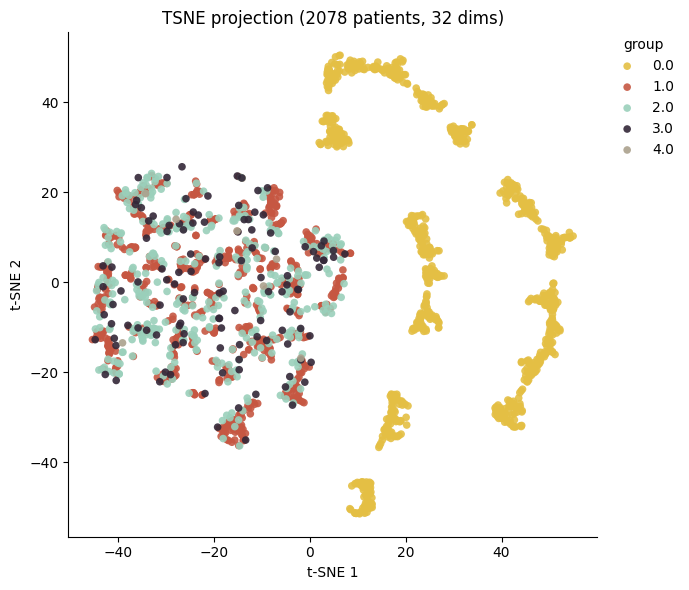

In [9]:
idx = node_order['KG'].values
fig = plot_patient_embeddings(pd.DataFrame(emb.numpy(),index=idx) , labels , method='TSNE', palette=wesanderson.FantasticFox2_5.hex_colors)

In [10]:
fig['fig'].savefig('KGEmbeddings.svg')

In [11]:
import torch
from torch_geometric.utils import from_networkx
import networkx as nx

emb, model = node2vec_gpu_embedding(
    edge_index=edge_index['PSN'],
    num_nodes=edge_index['PSN'].max().numpy()+1,
    embedding_dim=32,
    epochs=500,
    device="cuda",   # will fall back to CPU if not available
    batch_size=512,
)

print(emb.shape)  # torch.Size([34, 64])

Epoch 001/500 | loss=2.7991
Epoch 010/500 | loss=1.6688
Epoch 020/500 | loss=1.1475
Epoch 030/500 | loss=0.9409
Epoch 040/500 | loss=0.8590
Epoch 050/500 | loss=0.8206
Epoch 060/500 | loss=0.7976
Epoch 070/500 | loss=0.7824
Epoch 080/500 | loss=0.7723
Epoch 090/500 | loss=0.7671
Epoch 100/500 | loss=0.7603
Epoch 110/500 | loss=0.7620
Epoch 120/500 | loss=0.7598
Epoch 130/500 | loss=0.7565
Epoch 140/500 | loss=0.7526
Epoch 150/500 | loss=0.7533
Epoch 160/500 | loss=0.7509
Epoch 170/500 | loss=0.7510
Epoch 180/500 | loss=0.7494
Epoch 190/500 | loss=0.7519
Epoch 200/500 | loss=0.7486
Epoch 210/500 | loss=0.7499
Epoch 220/500 | loss=0.7498
Epoch 230/500 | loss=0.7494
Epoch 240/500 | loss=0.7480
Epoch 250/500 | loss=0.7484
Epoch 260/500 | loss=0.7464
Epoch 270/500 | loss=0.7485
Epoch 280/500 | loss=0.7474
Epoch 290/500 | loss=0.7478
Epoch 300/500 | loss=0.7478
Epoch 310/500 | loss=0.7495
Epoch 320/500 | loss=0.7462
Epoch 330/500 | loss=0.7492
Epoch 340/500 | loss=0.7463
Epoch 350/500 | loss

In [15]:
idx = node_order['PSN'].values
labels = node_labels(g_psn).loc[idx].sum(axis=1) 
healthy = node_labels(g_psn).loc[idx][3][node_labels(g_psn).loc[idx][3] == 1].index
labels[healthy] = 0

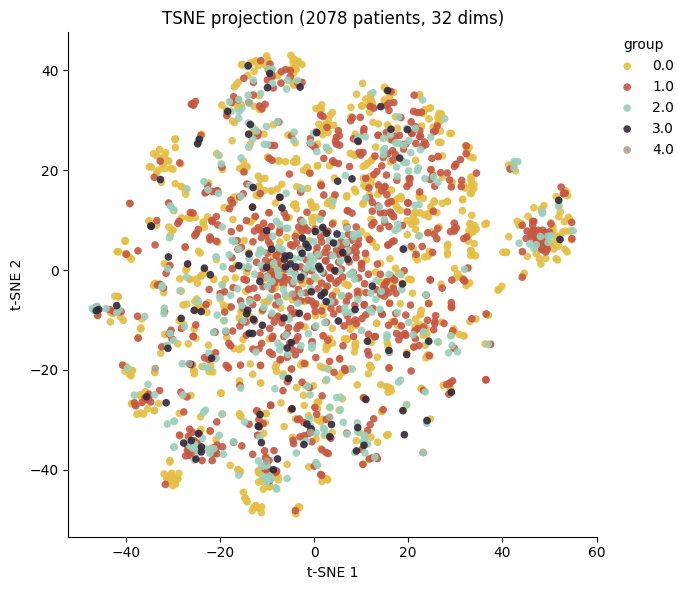

In [18]:
idx = node_order['PSN'].values
fig = plot_patient_embeddings(pd.DataFrame(emb.numpy(),index=idx) , labels , method='TSNE', palette=wesanderson.FantasticFox2_5.hex_colors)

In [19]:
fig['fig'].savefig('PSNEmbeddings.svg')

In [23]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

from palettable.wesanderson import Darjeeling2_5


In [46]:
H = emb
best_k = 5
RANDOM_STATE = 42
N = H.shape[0]
from palettable import wesanderson
PALETTE = wesanderson.Darjeeling2_5.hex_colors
FDR_ALPHA = 0.05

In [40]:
y = node_labels(g).values

Cluster membership matrix shape: (2078, 5)


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
id,,,,,
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,1,0
3,0,0,0,0,1
4,0,0,0,0,1



Cluster sizes:


,cluster,size
0,0,194
1,1,1
2,2,98
3,3,120
4,4,1665


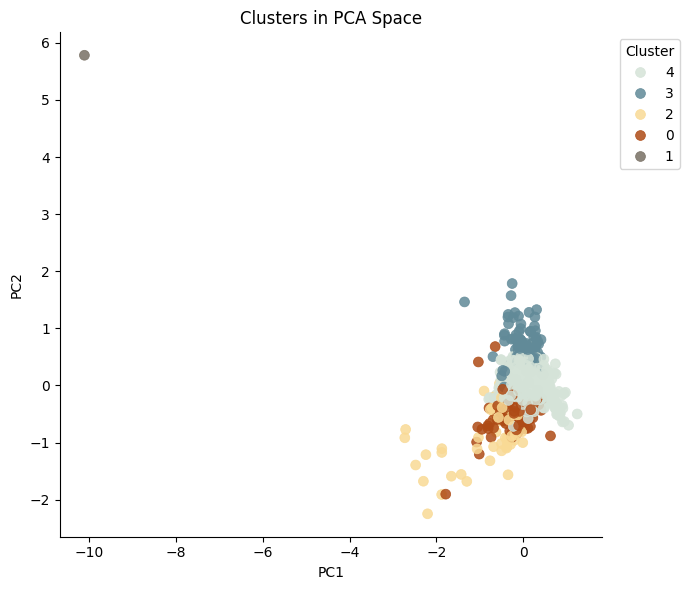

/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


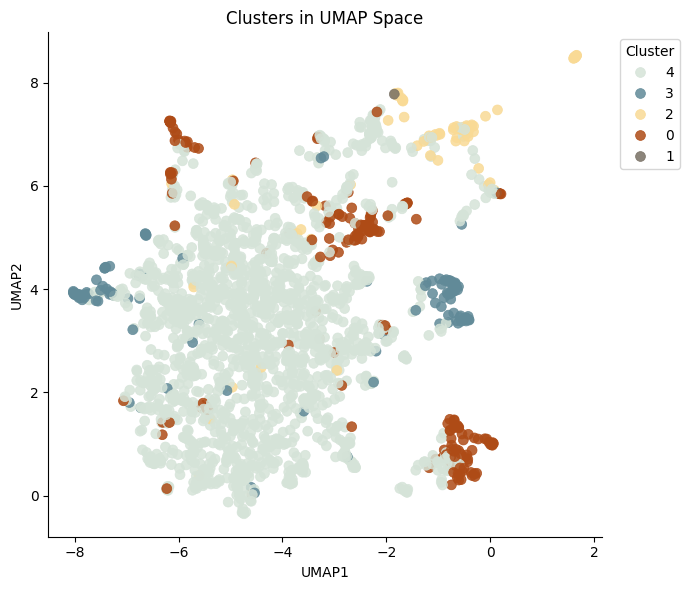


Per-cluster label proportions:


,cluster_size,CAD,CKD,DMT2,Healthy,OST
cluster,,,,,,
0,194,0.298969,0.288660,0.201031,0.365979,0.185567
1,1,0.000000,0.000000,0.000000,0.000000,1.000000
2,98,0.244898,0.255102,0.163265,0.448980,0.153061
3,120,0.283333,0.258333,0.191667,0.408333,0.208333
4,1665,0.238438,0.231832,0.204204,0.417417,0.195195


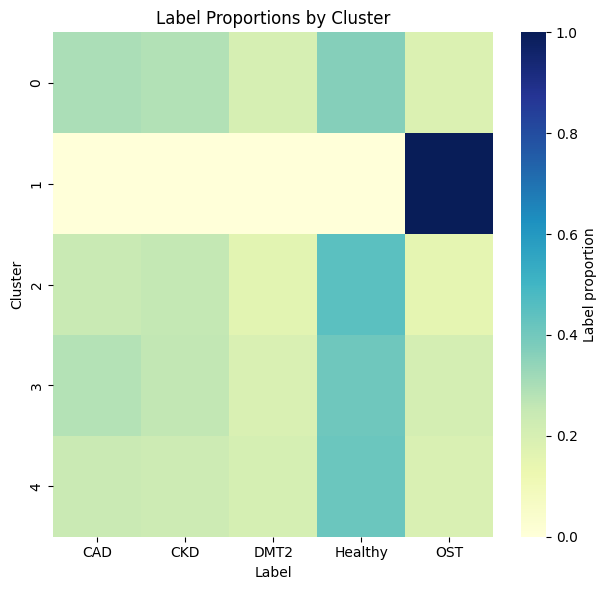


Top enriched labels per cluster:

Cluster 0


NameError: name 'TOP_N_ENRICHED' is not defined

In [47]:
kmeans = KMeans(n_clusters=int(best_k), n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(H)

# Binary membership matrix: ids x clusters
unique_clusters = np.sort(np.unique(clusters))
n_clusters = len(unique_clusters)

cluster_membership = np.zeros((N, n_clusters), dtype=np.int8)
cluster_membership[np.arange(N), clusters] = 1

df_cluster_membership = pd.DataFrame(
    cluster_membership,
    index=np.arange(N),
    columns=[f"cluster_{c}" for c in unique_clusters]
)
df_cluster_membership.index.name = "id"

print("Cluster membership matrix shape:", cluster_membership.shape)
display(df_cluster_membership.head())

np.save("/work/gr-fe/bryan/data/SHCS/03_final/mogsage_cluster_membership.npy", cluster_membership)

df_meta = pd.DataFrame({
    "cluster": clusters
})

cluster_sizes = (
    df_meta["cluster"]
    .value_counts()
    .sort_index()
    .rename("size")
    .reset_index()
    .rename(columns={"index": "cluster"})
)

print("\nCluster sizes:")
display(cluster_sizes)

# ── 5. 2D visualization (PCA + UMAP if available) ────────────────────────────
# PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
H_pca2 = pca_2d.fit_transform(H)

df_plot_pca = pd.DataFrame({
    "PC1": H_pca2[:, 0],
    "PC2": H_pca2[:, 1],
    "cluster": clusters.astype(str)
})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=PALETTE[:int(best_k)] if best_k <= len(PALETTE) else "tab10",
    s=50,
    alpha=0.85,
    edgecolor=None
)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

# UMAP 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE
)
H_umap = reducer.fit_transform(H)

df_plot_umap = pd.DataFrame({
    "UMAP1": H_umap[:, 0],
    "UMAP2": H_umap[:, 1],
    "cluster": clusters.astype(str)
})

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df_plot_umap,
    x="UMAP1",
    y="UMAP2",
    hue="cluster",
    palette=PALETTE[:int(best_k)] if best_k <= len(PALETTE) else "tab10",
    s=50,
    alpha=0.85,
    edgecolor=None
)
plt.title("Clusters in UMAP Space")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig('GNNEmbeddings.svg')
plt.show()

# ── 6. Per-cluster label proportions ─────────────────────────────────────────
# global proportion per label
global_prop = y.mean(axis=0)

cluster_prop_rows = []
for c in sorted(np.unique(clusters)):
    idx = np.where(clusters == c)[0]
    prop = y[idx].mean(axis=0)

    row = {"cluster": c, "cluster_size": len(idx)}
    for j, name in enumerate(label_names):
        row[name] = prop[j]
    cluster_prop_rows.append(row)

df_cluster_props = pd.DataFrame(cluster_prop_rows).set_index("cluster")

print("\nPer-cluster label proportions:")
display(df_cluster_props.iloc[:, :min(10, df_cluster_props.shape[1])])

# Heatmap of proportions
heatmap_df = df_cluster_props.drop(columns=["cluster_size"], errors="ignore")
plt.figure(figsize=(min(18, 0.45 * heatmap_df.shape[1] + 4), 0.8 * heatmap_df.shape[0] + 2))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=False,
    cbar_kws={"label": "Label proportion"}
)
plt.title("Label Proportions by Cluster")
plt.xlabel("Label")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# ── 7. Enrichment testing per cluster x label ────────────────────────────────
# For each cluster c and label j, test whether label j is enriched in cluster c
# versus the rest of the dataset using one-sided Fisher exact test.
enrichment_rows = []

for c in sorted(np.unique(clusters)):
    in_cluster = (clusters == c)
    out_cluster = ~in_cluster

    n_in = in_cluster.sum()
    n_out = out_cluster.sum()

    for j, name in enumerate(label_names):
        label_in = y[in_cluster, j].sum()
        label_out = y[out_cluster, j].sum()

        nonlabel_in = n_in - label_in
        nonlabel_out = n_out - label_out

        table = np.array([
            [label_in, nonlabel_in],
            [label_out, nonlabel_out]
        ])

        # One-sided test for enrichment (greater odds inside cluster)
        odds_ratio, pval = fisher_exact(table, alternative="greater")

        prop_in = label_in / n_in if n_in > 0 else np.nan
        prop_out = label_out / n_out if n_out > 0 else np.nan
        fold_enrichment = (prop_in + 1e-12) / (prop_out + 1e-12)

        enrichment_rows.append({
            "cluster": c,
            "label": name,
            "n_in_cluster": n_in,
            "label_count_in_cluster": int(label_in),
            "label_count_out_cluster": int(label_out),
            "prop_in_cluster": prop_in,
            "prop_out_cluster": prop_out,
            "global_prop": global_prop[j],
            "fold_enrichment": fold_enrichment,
            "odds_ratio": odds_ratio,
            "p_value": pval,
        })

df_enrich = pd.DataFrame(enrichment_rows)

# FDR correction across all cluster-label tests
reject, qvals, _, _ = multipletests(df_enrich["p_value"].values, alpha=FDR_ALPHA, method="fdr_bh")
df_enrich["q_value"] = qvals
df_enrich["significant"] = reject

# Sort useful summary
df_enrich = df_enrich.sort_values(
    ["cluster", "q_value", "fold_enrichment"],
    ascending=[True, True, False]
)

print("\nTop enriched labels per cluster:")
for c in sorted(df_enrich["cluster"].unique()):
    print(f"\nCluster {c}")
    df_top = (
        df_enrich[df_enrich["cluster"] == c]
        .sort_values(["q_value", "fold_enrichment"], ascending=[True, False])
        .head(TOP_N_ENRICHED)
    )
    display(
        df_top[[
            "label",
            "prop_in_cluster",
            "prop_out_cluster",
            "fold_enrichment",
            "odds_ratio",
            "p_value",
            "q_value",
            "significant"
        ]]
        .style
        .format({
            "prop_in_cluster": "{:.3f}",
            "prop_out_cluster": "{:.3f}",
            "fold_enrichment": "{:.2f}",
            "odds_ratio": "{:.2f}",
            "p_value": "{:.3e}",
            "q_value": "{:.3e}",
        })
    )

# ── 8. Visual summary of significant enrichments ─────────────────────────────
# Keep only significant enrichments and show fold enrichment as a heatmap
df_sig = df_enrich[df_enrich["significant"]].copy()

if len(df_sig) > 0:
    enrich_mat = df_sig.pivot(index="cluster", columns="label", values="fold_enrichment").fillna(1.0)

    plt.figure(figsize=(min(18, 0.45 * enrich_mat.shape[1] + 4), 0.8 * enrich_mat.shape[0] + 2))
    sns.heatmap(
        enrich_mat,
        cmap="rocket_r",
        annot=False,
        cbar_kws={"label": "Fold enrichment"}
    )
    plt.title("Significant Label Enrichment by Cluster (FDR-corrected)")
    plt.xlabel("Label")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo significant enrichments found at the chosen FDR threshold.")

# ── 9. Cluster-wise summary table ────────────────────────────────────────────
summary_rows = []
for c in sorted(np.unique(clusters)):
    idx = np.where(clusters == c)[0]
    size = len(idx)

    sig_labels = (
        df_enrich[(df_enrich["cluster"] == c) & (df_enrich["significant"])]
        .sort_values(["q_value", "fold_enrichment"], ascending=[True, False])
    )

    top_labels = sig_labels["label"].head(5).tolist()
    summary_rows.append({
        "cluster": c,
        "size": size,
        "fraction_of_dataset": size / N,
        "n_significant_enriched_labels": sig_labels.shape[0],
        "top_enriched_labels": ", ".join(top_labels) if top_labels else "-"
    })

df_cluster_summary = pd.DataFrame(summary_rows).set_index("cluster")

print("\nCluster summary:")
display(
    df_cluster_summary.style.format({
        "fraction_of_dataset": "{:.3f}"
    })
)

In [45]:
label_names = ['CAD' , 'CKD' , 'DMT2' , 'Healthy' , 'OST']